
# Neural Network From Scratch - 3 Layer Network

This notebook demonstrates:

- A 3-layer neural network (Input → Hidden → Output)
- Weight matrices and bias vectors
- Activation functions
- Forward propagation
- Backpropagation
- Training using gradient descent
- Synthetic dataset generation
- Visualization of the neural network 



In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



# Step 1 - Generate Synthetic Data

We create a simple 2D classification dataset.


In [40]:

def generate_synthetic_data(samples=500):
    X = np.random.randn(samples, 2)

    # Circular decision boundary
    radius = X[:, 0]**2 + X[:, 1]**2

    y = (radius < 1.5).astype(int)
    y = y.reshape(-1, 1)

    return X, y

X, y = generate_synthetic_data()

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


Input Shape : (500, 2)
Target Shape: (500, 1)


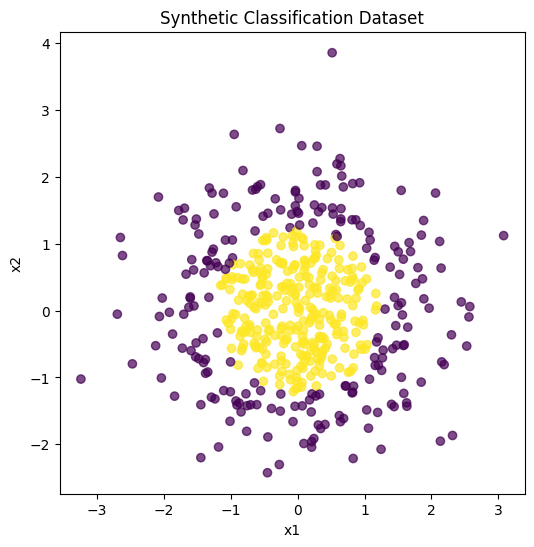

In [41]:

# Visualize dataset

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.flatten(),
    alpha=0.7
)

plt.title("Synthetic Classification Dataset")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()



# Step 2 - Activation Functions


In [42]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)


def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)



# Step 3 - Initialize Parameters

Weights and biases are represented as matrices.

Architecture:

- Input Layer  : 2 neurons
- Hidden Layer : 5 neurons
- Output Layer : 1 neuron


In [43]:

def initialize_parameters(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))

    # parameters returned as a tuple: (W1, b1, W2, b2)
    return (W1, b1, W2, b2)

parameters = initialize_parameters(2, 5, 1)

# unpack and display
W1, b1, W2, b2 = parameters
print("W1:\n", W1)
print("b1:\n", b1)
print("W2:\n", W2)
print("b2:\n", b2)


W1:
 [[ 0.13993554  0.09246337  0.00596304 -0.06469368  0.06982233]
 [ 0.03934854  0.08951932  0.06351718  0.10495527 -0.05352352]]
b1:
 [[0. 0. 0. 0. 0.]]
W2:
 [[ 0.13173941]
 [ 0.01975996]
 [ 0.20752609]
 [-0.06891878]
 [ 0.17359638]]
b2:
 [[0.]]



# Step 4 - Forward Propagation


In [44]:

def forward_propagation(X, parameters):
    # unpack parameters tuple (W1, b1, W2, b2)
    W1, b1, W2, b2 = parameters

    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # return cache as a tuple (Z1, A1, Z2, A2)
    cache = (Z1, A1, Z2, A2)

    return A2, cache

predictions, cache = forward_propagation(X, parameters)

print(predictions[:5])


[[0.50410203]
 [0.50911425]
 [0.5       ]
 [0.51534891]
 [0.50016375]]



# Step 5 - Loss Function


In [45]:

def compute_loss(y_true, y_pred):
    epsilon = 1e-8
    loss = -np.mean(
        y_true * np.log(y_pred + epsilon) +
        (1 - y_true) * np.log(1 - y_pred + epsilon)
    )
    return loss


loss = compute_loss(y, predictions)
print("Initial Loss:", loss)

Initial Loss: 0.6960905313683378



# Step 6 - Backpropagation


In [46]:

def backward_propagation(X, y, parameters, cache):
    m = X.shape[0]

    # unpack parameters and cache tuples
    W1, b1, W2, b2 = parameters
    Z1, A1, Z2, A2 = cache

    # Output layer gradients
    dZ2 = A2 - y

    dW2 = (1 / m) * np.dot(A1.T, dZ2)

    db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (1 / m) * np.dot(X.T, dZ1)

    db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

    # return gradients as a tuple (dW1, db1, dW2, db2)
    return (dW1, db1, dW2, db2)



# Step 7 - Update Parameters


In [47]:

def update_parameters(parameters, gradients, learning_rate):
    # unpack tuples
    W1, b1, W2, b2 = parameters
    dW1, db1, dW2, db2 = gradients

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    # return updated parameters as tuple
    return (W1, b1, W2, b2)



# Step 8 - Training Loop


In [48]:

def train_neural_network(X, y, hidden_size=5, learning_rate=0.1, epochs=1000 ):
    input_size = X.shape[1]
    output_size = 1

    parameters = initialize_parameters(
        input_size,
        hidden_size,
        output_size
    )
    loss_history = []

    for epoch in range(epochs):
        # Forward propagation
        predictions, cache = forward_propagation(
            X,
            parameters
        )

        # Compute loss
        loss = compute_loss(y, predictions)
        loss_history.append(loss)

        # Backpropagation
        gradients = backward_propagation(
            X,
            y,
            parameters,
            cache
        )

        # Update parameters
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss = {loss:.4f}")

    return parameters, loss_history


trained_parameters, loss_history = train_neural_network(
    X,
    y,
    hidden_size=5,
    learning_rate=0.1,
    epochs=1000
)


Epoch    0 | Loss = 0.6930
Epoch  100 | Loss = 0.6743
Epoch  200 | Loss = 0.6468
Epoch  300 | Loss = 0.6120
Epoch  400 | Loss = 0.5583
Epoch  500 | Loss = 0.4936
Epoch  600 | Loss = 0.4082
Epoch  700 | Loss = 0.3315
Epoch  800 | Loss = 0.2837
Epoch  900 | Loss = 0.2520



# Step 9 - Visualize Training Loss


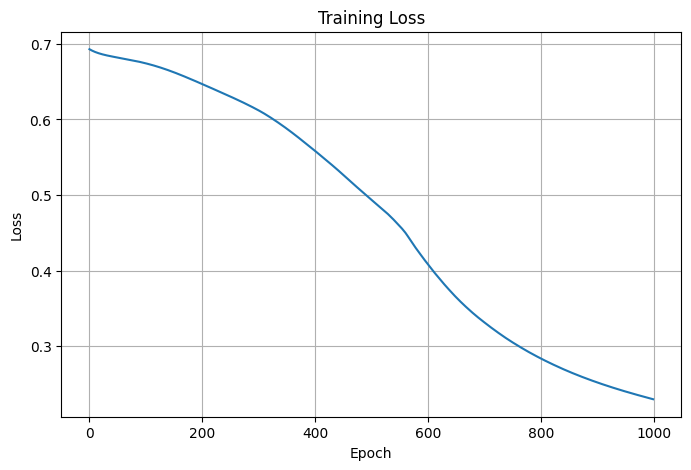

In [49]:

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()



# Step 10 - Evaluate Accuracy


In [50]:

def predict(X, parameters):
    predictions, _ = forward_propagation(X, parameters)
    return (predictions > 0.5).astype(int)

predicted_labels = predict(X, trained_parameters)
accuracy = np.mean(predicted_labels == y)

print("Accuracy:", accuracy)


Accuracy: 0.946



# Step 11 - Visualize Decision Boundary


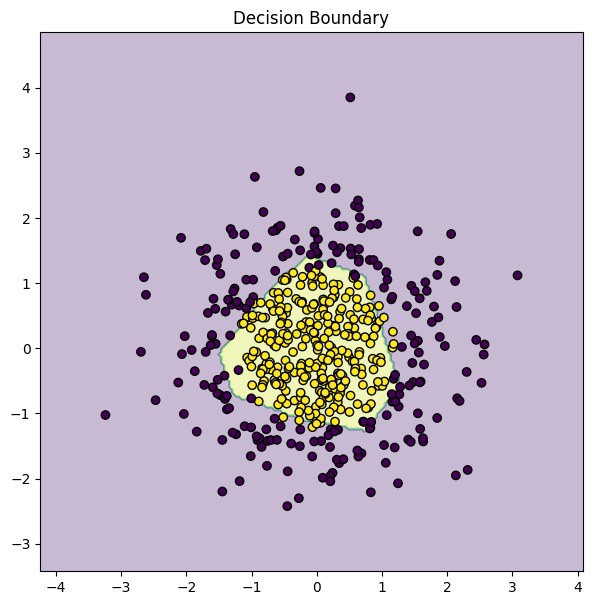

In [51]:

def plot_decision_boundary(X, y, parameters):

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = predict(grid, parameters)

    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(7,7))

    plt.contourf(xx, yy, predictions, alpha=0.3)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y.flatten(),
        edgecolors='k'
    )

    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(X, y, trained_parameters)



# Step 12 - Neural Network Visualization Using PyVis

- Each node represents a neuron
- Thickness of connections represents weight magnitude
- Green edges = positive weights
- Red edges = negative weights


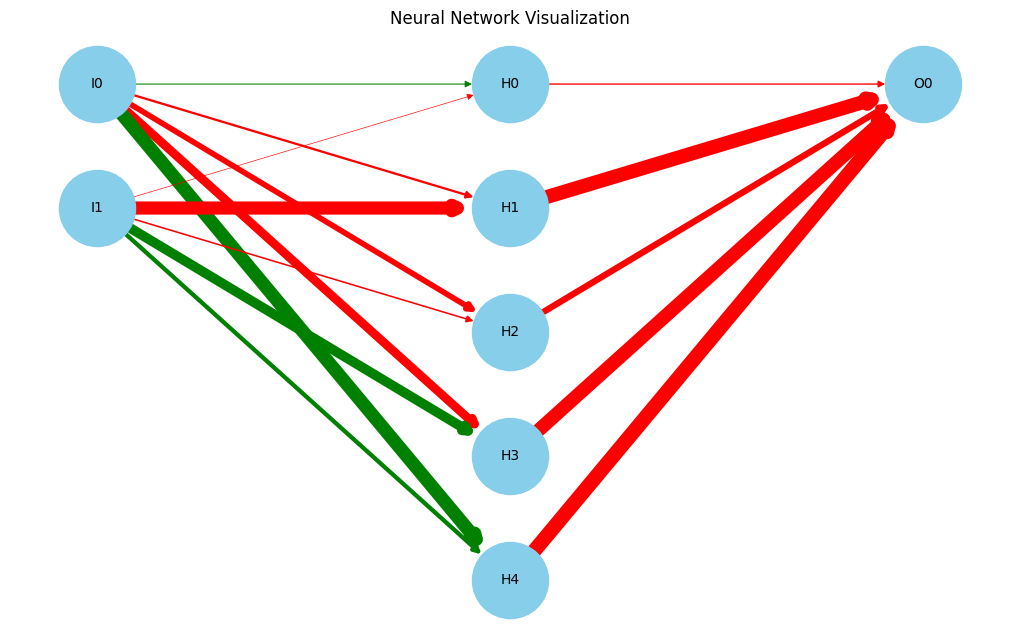

In [52]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def visualize_network_inline(parameters):
    # unpack parameter tuple
    W1, b1, W2, b2 = parameters

    G = nx.DiGraph()

    input_size = W1.shape[0]
    hidden_size = W1.shape[1]
    output_size = W2.shape[1]

    positions = {}


    for i in range(input_size):
        node = f"I{i}"
        G.add_node(node)
        positions[node] = (0, -i)

    for j in range(hidden_size):
        node = f"H{j}"
        G.add_node(node)
        positions[node] = (1, -j)



    for k in range(output_size):
        node = f"O{k}"
        G.add_node(node)
        positions[node] = (2, -k)
 
    edge_widths = []
    edge_colors = []

    for i in range(input_size):
        for j in range(hidden_size):
            weight = W1[i, j]
            G.add_edge(f"I{i}", f"H{j}")
            edge_widths.append(abs(weight) * 5)
            edge_colors.append(
                "green" if weight > 0 else "red"
            )

    for j in range(hidden_size):
        for k in range(output_size):
            weight = W2[j, k]
            G.add_edge(f"H{j}", f"O{k}")
            edge_widths.append(abs(weight) * 5)
            edge_colors.append(
                "green" if weight > 0 else "red"
            )


    plt.figure(figsize=(10, 6))

    nx.draw(
        G,
        pos=positions,
        with_labels=True,

        node_size=3000,
        node_color="skyblue",

        font_size=10,

        width=edge_widths,
        edge_color=edge_colors,

        arrows=True
    )

    plt.title("Neural Network Visualization")
    plt.axis("off")
    plt.show()


visualize_network_inline(trained_parameters)


# Summary

This notebook demonstrated:

1. Building a neural network from scratch
2. Using matrix-based weights and biases
3. Forward propagation
4. Backpropagation
5. Gradient descent training
6. Visualization of learning
7. Interactive neural network graph visualization with PyVis
